# 24. Risk-Managed Trading System

## Objective
Improve profitability through **risk control** and **capital allocation** on top of Step-23 predictions, without changing underlying models.

This notebook implements:
1. Load Step-23 output
2. Remove LOW regime trades
3. Allocate capital (MEDIUM 70%, HIGH 30%)
4. Volatility scaling (`weight = signal / volatility`)
5. Daily trade cap (max 10, strongest signals)
6. Stop-loss (-2%) and take-profit (+4%)
7. Backtest + benchmark comparison
8. Save `final_risk_managed_strategy.parquet`

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 260)
pd.set_option('display.width', 240)

MAX_TRADES_PER_DAY = 10
STOP_LOSS = -0.02
TAKE_PROFIT = 0.04
ANNUALIZATION_DAYS = 252
REGIME_CAPITAL = {'MEDIUM': 0.70, 'HIGH': 0.30}

logger = logging.getLogger('risk_managed_system')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


ROOT = resolve_project_root()
BASE = ROOT / 'ml_pipeline'

STEP23_PATH = BASE / 'Market_Data' / 'final' / 'final_regime_aware_strategy.parquet'
STEP20_PATH = BASE / 'Market_Data' / 'final' / 'final_strategy_results.parquet'
PROCESSED_PATH = BASE / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet'
OUT_PATH = BASE / 'Market_Data' / 'final' / 'final_risk_managed_strategy.parquet'

assert STEP23_PATH.exists(), f'Missing required input: {STEP23_PATH}'
assert STEP20_PATH.exists(), f'Missing required benchmark file: {STEP20_PATH}'
assert PROCESSED_PATH.exists(), f'Missing processed dataset: {PROCESSED_PATH}'

step23 = pd.read_parquet(STEP23_PATH).copy()
step23['Date'] = pd.to_datetime(step23['Date'])
step23['regime_label'] = step23['regime_label'].astype(str).str.upper()
assert {'Ticker', 'Date', 'regime_label', 'probability', 'future_return'}.issubset(step23.columns)

if 'signal_raw' in step23.columns:
    step23['signal_strength'] = step23['signal_raw'].astype(float)
else:
    step23['signal_strength'] = (step23['probability'] - 0.5).abs()

if 'selected_trade' in step23.columns:
    base = step23[step23['selected_trade']].copy()
else:
    base = step23.copy()

# STEP 2: Remove LOW regime trades.
base = base[base['regime_label'].isin(['MEDIUM', 'HIGH'])].copy()

vol_df = pd.read_parquet(PROCESSED_PATH, columns=['Ticker', 'Date', 'Volatility_20']).copy()
vol_df['Date'] = pd.to_datetime(vol_df['Date'])
base = base.merge(vol_df, on=['Ticker', 'Date'], how='left')
base['Volatility_20'] = base['Volatility_20'].replace(0, np.nan)
base['Volatility_20'] = base['Volatility_20'].fillna(base['Volatility_20'].median())
base['Volatility_20'] = base['Volatility_20'].clip(lower=1e-6)

base['capital_fraction'] = base['regime_label'].map(REGIME_CAPITAL).astype(float)

# STEP 4: Volatility scaling.
base['vol_scaled_signal'] = base['signal_strength'] / base['Volatility_20']
base['selection_score'] = base['signal_strength']

# STEP 5: Max 10 trades/day by strongest signal.
base = base.sort_values(['Date', 'selection_score'], ascending=[True, False]).copy()
base['rank_in_day'] = base.groupby('Date').cumcount() + 1
base['selected_trade'] = base['rank_in_day'] <= MAX_TRADES_PER_DAY
trade_df = base[base['selected_trade']].copy()

# STEP 3 + STEP 4: capital allocation and daily normalization.
trade_df['direction'] = np.where(trade_df['probability'] > 0.5, 1, np.where(trade_df['probability'] < 0.5, -1, 0))
trade_df['alloc_score'] = trade_df['capital_fraction'] * trade_df['vol_scaled_signal']
trade_df['alloc_sum'] = trade_df.groupby('Date')['alloc_score'].transform('sum')
trade_df['weight_abs'] = np.where(trade_df['alloc_sum'] > 0, trade_df['alloc_score'] / trade_df['alloc_sum'], 0.0)
trade_df['weight'] = trade_df['weight_abs'] * trade_df['direction']

logger.info('Step-23 rows: %s', f'{len(step23):,}')
logger.info('Tradable rows after filters: %s', f'{len(base):,}')
logger.info('Selected risk-managed trades: %s', f'{len(trade_df):,}')
display(trade_df[['Ticker', 'Date', 'regime_label', 'signal_strength', 'Volatility_20', 'vol_scaled_signal', 'capital_fraction', 'weight']].head(12))


[INFO] Step-23 rows: 22,643
[INFO] Tradable rows after filters: 802
[INFO] Selected risk-managed trades: 802


,Ticker,Date,regime_label,signal_strength,Volatility_20,vol_scaled_signal,capital_fraction,weight
0,UNIONBANK,2025-01-02,MEDIUM,0.234227,0.015444,15.166385,0.7,-1.000000
1,SHREECEM,2025-01-03,MEDIUM,0.232401,0.017170,13.535259,0.7,0.528328
2,UNIONBANK,2025-01-03,MEDIUM,0.197881,0.016376,12.083763,0.7,-0.471672
3,HDFCAMC,2025-01-06,MEDIUM,0.226996,0.015774,14.390446,0.7,0.527605
4,TVSMOTOR,2025-01-06,MEDIUM,0.226762,0.017599,12.884604,0.7,0.472395
5,DLF,2025-01-07,MEDIUM,0.223002,0.015357,14.521319,0.7,-0.582487
6,JIOFIN,2025-01-07,MEDIUM,0.185365,0.017809,10.408531,0.7,-0.417513
7,CUMMINSIND,2025-01-08,MEDIUM,0.177908,0.017872,9.954656,0.7,-1.000000
12,TVSMOTOR,2025-01-09,MEDIUM,0.380240,0.017400,21.853398,0.7,0.199507
13,UNITDSPR,2025-01-09,MEDIUM,0.306692,0.015624,19.629958,0.7,0.179208


,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate
0,Risk-managed (Step-24),0.8839,3.9402,-0.0726,0.5514
1,Step-20 strategy,0.1119,2.5821,0.0000,0.0324
2,Buy & Hold,0.2395,2.0541,-0.0868,0.5838
3,Step-23 strategy,0.0775,0.5309,-0.1858,0.5405


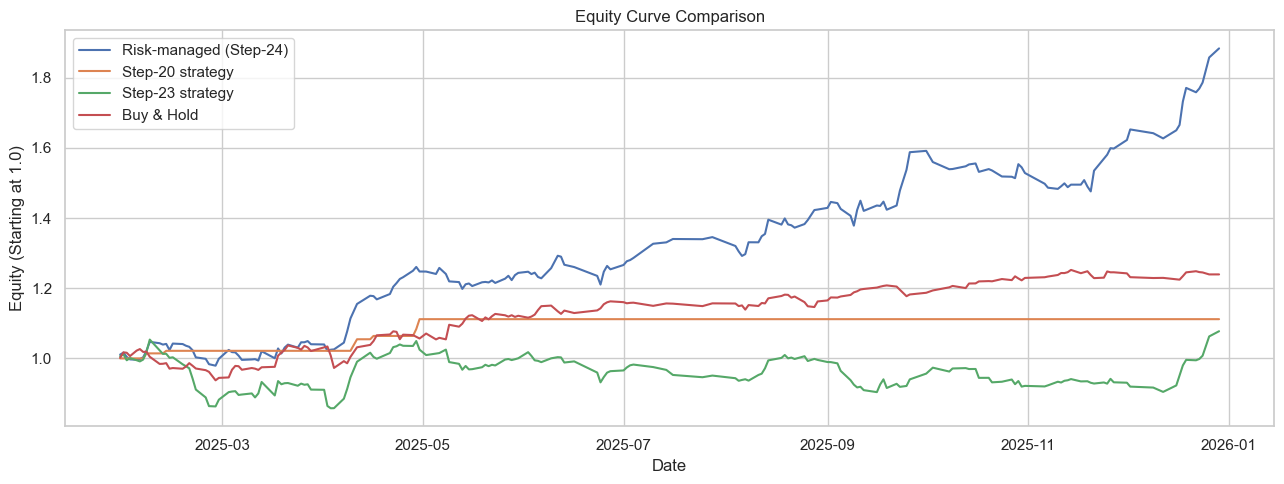

In [3]:
# STEP 6: Risk management (stop-loss/take-profit) applied on directional trade return.
trade_df['unit_trade_return'] = trade_df['direction'] * trade_df['future_return']
trade_df['unit_trade_return_risk_managed'] = trade_df['unit_trade_return'].clip(lower=STOP_LOSS, upper=TAKE_PROFIT)
trade_df['strategy_return'] = trade_df['weight_abs'] * trade_df['unit_trade_return_risk_managed']
trade_df['gross_return_no_risk_cap'] = trade_df['weight'] * trade_df['future_return']

daily_risk = trade_df.groupby('Date', as_index=True)['strategy_return'].sum().sort_index()


def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def summarize(name: str, daily_returns: pd.Series) -> Dict[str, float]:
    s = daily_returns.sort_index()
    if len(s) == 0:
        return {
            'Strategy': name,
            'Total return': np.nan,
            'Sharpe ratio': np.nan,
            'Max drawdown': np.nan,
            'Win rate': np.nan,
        }
    eq = (1.0 + s).cumprod()
    return {
        'Strategy': name,
        'Total return': float(eq.iloc[-1] - 1.0),
        'Sharpe ratio': sharpe_ratio(s),
        'Max drawdown': max_drawdown(eq),
        'Win rate': float((s > 0).mean()),
    }


# STEP 7: Benchmark comparison.
step20 = pd.read_parquet(STEP20_PATH).copy()
step20['Date'] = pd.to_datetime(step20['Date'])
daily_step20 = step20.groupby('Date', as_index=True)['net_return'].sum().sort_index()

step23_ref = pd.read_parquet(STEP23_PATH).copy()
step23_ref['Date'] = pd.to_datetime(step23_ref['Date'])
daily_step23 = step23_ref.groupby('Date', as_index=True)['strategy_return'].sum().sort_index()

market = pd.read_parquet(PROCESSED_PATH, columns=['Ticker', 'Date', 'Close']).copy()
market['Date'] = pd.to_datetime(market['Date'])
market = market.sort_values(['Ticker', 'Date']).reset_index(drop=True)
market['close_t1'] = market.groupby('Ticker', sort=False)['Close'].shift(-1)
market['daily_return'] = market['close_t1'] / market['Close'] - 1.0
market = market.dropna(subset=['daily_return'])
buy_hold = market[(market['Date'] >= daily_risk.index.min()) & (market['Date'] <= daily_risk.index.max())].copy()
buy_hold['w'] = 1.0 / buy_hold.groupby('Date')['Ticker'].transform('count')
buy_hold['bh_ret'] = buy_hold['w'] * buy_hold['daily_return']
daily_bh = buy_hold.groupby('Date', as_index=True)['bh_ret'].sum().sort_index()

common = daily_risk.index.intersection(daily_step20.index).intersection(daily_step23.index).intersection(daily_bh.index)
cmp_risk = daily_risk.loc[common]
cmp_step20 = daily_step20.loc[common]
cmp_step23 = daily_step23.loc[common]
cmp_bh = daily_bh.loc[common]

metrics = pd.DataFrame([
    summarize('Risk-managed (Step-24)', cmp_risk),
    summarize('Step-20 strategy', cmp_step20),
    summarize('Step-23 strategy', cmp_step23),
    summarize('Buy & Hold', cmp_bh),
]).sort_values('Sharpe ratio', ascending=False).reset_index(drop=True)
display(metrics.round(4))

equity = pd.DataFrame({
    'Risk-managed (Step-24)': (1.0 + cmp_risk).cumprod(),
    'Step-20 strategy': (1.0 + cmp_step20).cumprod(),
    'Step-23 strategy': (1.0 + cmp_step23).cumprod(),
    'Buy & Hold': (1.0 + cmp_bh).cumprod(),
})

plt.figure(figsize=(13, 5))
for col in equity.columns:
    plt.plot(equity.index, equity[col], label=col)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Equity (Starting at 1.0)')
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
# STEP 8: Save final risk-managed strategy output.
save_cols = [
    'Ticker', 'Date', 'regime_label', 'probability', 'future_return',
    'signal_strength', 'Volatility_20', 'capital_fraction',
    'vol_scaled_signal', 'rank_in_day', 'selected_trade',
    'direction', 'alloc_score', 'weight_abs', 'weight',
    'unit_trade_return', 'unit_trade_return_risk_managed',
    'gross_return_no_risk_cap', 'strategy_return'
]

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
trade_df[save_cols].to_parquet(OUT_PATH, index=False)

print(f'Saved output: {OUT_PATH}')
print('Notebook 24 completed: risk-managed trading system ready.')


Saved output: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\final_risk_managed_strategy.parquet
Notebook 24 completed: risk-managed trading system ready.
